# VocEd Lab 01 — Exploratory Segmentation*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/01_exploratory_segmentation.ipynb)

In this notebook we explore a dataset of cytology images and begin segmenting them using the
simplest possible tool: **intensity thresholding**.  The goal of the larger project is to train a
deep-learning model that predicts the **nucleus-to-cytoplasm (N/C) ratio** — a key diagnostic
measurement in pathology.  Before we reach deep learning, we need to understand what the data
looks like, how it is stored, and how well a naive approach already performs.

By the end of this lab you will be able to:
- Load and inspect a NumPy image dataset.
- Visualise RGB images alongside their ground-truth segmentation masks.
- Convert an RGB image to grayscale **by hand**, using the standard luminance formula.
- Build a simple two-threshold segmenter that labels every pixel as *background*, *cytoplasm*, or *nucleus*.
- Quantify segmentation quality using the **Dice score**.

## 0. Setup — Clone the Repository

The cell below clones the VocEd GitHub repository directly into the current Colab directory
so that all image files are available locally.  You only need to run this once per session.

In [1]:
# Clone the repo
!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

Cloning into 'VocEd'...
remote: Enumerating objects: 663, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 663 (delta 55), reused 67 (delta 30), pack-reused 566 (from 1)
Receiving objects: 100% (663/663), 34.36 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Updating files: 100% (417/417), done.
/content/VocEd


## 1. Loading the Data

The dataset contains **200 paired files**.  Each pair consists of:

| Folder | Shape | dtype | Description |
|---|---|---|---|
| `imagedata/X/` | `(3, 256, 256)` | `float32` | RGB image, pixel values in `[0, 1]` |
| `imagedata/y/` | `(256, 256)` | `int64` | Segmentation mask — one integer label per pixel |

The mask labels are:
- `0` → background (slide glass / empty space)
- `1` → cytoplasm
- `2` → nucleus

Notice that the colour channels sit in **axis 0** (channel-first format).  This is the convention
used by PyTorch.  When we want to display an image we will need to transpose it to
`(256, 256, 3)` (channel-last), which is what Matplotlib expects.

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# ── Load data (already float32, channels-first) ──────────────────────────────

N = len(glob.glob("imagedata/X/*.npy"))

X = np.stack([np.load(f"imagedata/X/{i}.npy") for i in range(N)])   # (N, 3, 256, 256), float32
y = np.stack([np.load(f"imagedata/y/{i}.npy") for i in range(N)])   # (N, 256, 256), int64

print(f"X  shape : {X.shape}   dtype: {X.dtype}")
print(f"y  shape : {y.shape}   dtype: {y.dtype}")
print(f"Pixel range in X : [{X.min():.3f}, {X.max():.3f}]")
print(f"Unique labels in y: {np.unique(y)}")

X  shape : (200, 3, 256, 256)   dtype: float32
y  shape : (200, 256, 256)   dtype: int64
Pixel range in X : [0.000, 1.000]
Unique labels in y: [0 1 2]


## 2. Exploratory Analysis

Before building any model it is essential to *look at the data*.  We want to know:
- What do the raw images look like?
- How large are the nucleus and cytoplasm regions relative to the whole image?
- Is the dataset balanced (roughly equal class sizes), or heavily skewed?

The cells below answer these questions and build intuition for the threshold choices we will
make in the next section.

In [3]:
# ── Class distribution across the entire dataset ─────────────────────────────
label_names = {0: 'background', 1: 'cytoplasm', 2: 'nucleus'}

total_pixels = y.size

#image = np.array([[1,2,1],[0,1,2],[0,2,2]])
#print((image == 2).sum())
#print(image)

print("Average pixel class distribution (all 200 images):")
for cls in [0, 1, 2]:
    count = (y == cls).sum()
    print(f"  Class {cls} ({label_names[cls]:>12s}): {count:>10,}  ({100*count/total_pixels:.1f}%)")

Average pixel class distribution (all 200 images):
  Class 0 (  background):  4,714,960  (36.0%)
  Class 1 (   cytoplasm):  5,823,720  (44.4%)
  Class 2 (     nucleus):  2,568,520  (19.6%)


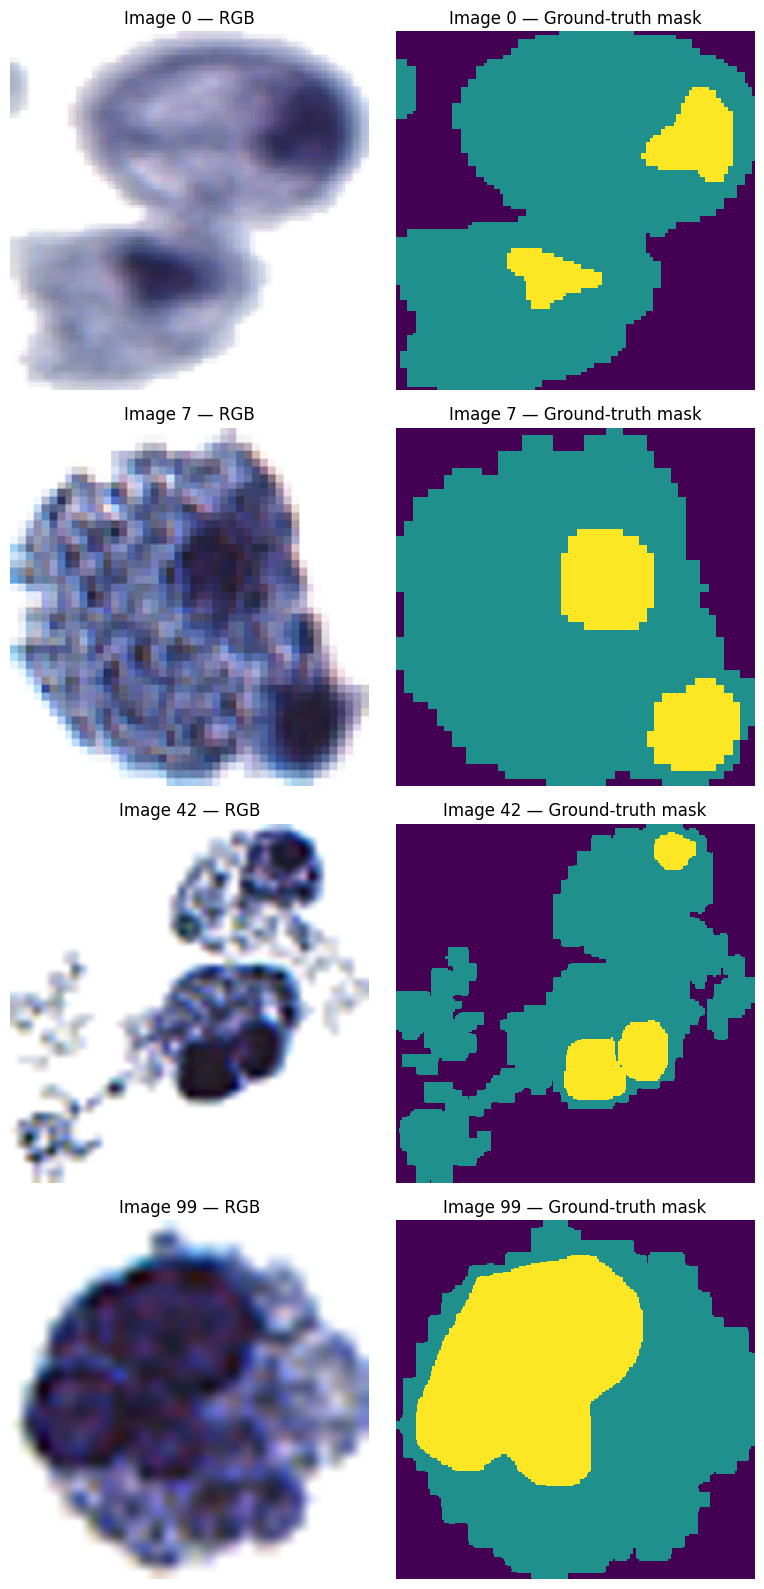

In [4]:
sample_ids = [0, 7, 42, 99]
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for row, idx in enumerate(sample_ids):
    axes[row, 0].imshow(X[idx].transpose(1, 2, 0))
    axes[row, 0].set_title(f"Image {idx} — RGB")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(y[idx], cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[row, 1].set_title(f"Image {idx} — Ground-truth mask")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

## 3. Grayscale Conversion

Colour information is valuable, but a single grayscale channel is easier to threshold.
We will convert image 7 to grayscale **without using any library function**, so that the
maths is completely transparent.

The standard **luminance formula** (ITU-R BT.601) is:

$$\text{gray} = 0.299 \cdot R \;+\; 0.587 \cdot G \;+\; 0.114 \cdot B$$

The weights reflect the human eye's different sensitivity to each colour channel — we are
most sensitive to green, moderately to red, and least to blue.

After the conversion we also plot the **per-class grayscale histogram**, which is the key
tool we will use to choose threshold values in the next section.

In [5]:
# ── Manual RGB → grayscale for image 7 ───────────────────────────────────────
IDX = 7
img7  = X[IDX]               # (3, 256, 256)
mask7 = y[IDX]               # (256, 256)

R, G, B = img7[0], img7[1], img7[2]   # each is (256, 256)
gray7   = 0.299 * R + 0.587 * G + 0.114 * B

print(f"Grayscale shape : {gray7.shape}")
print(f"Value range     : [{gray7.min():.3f}, {gray7.max():.3f}]")

Grayscale shape : (256, 256)
Value range     : [0.120, 1.000]


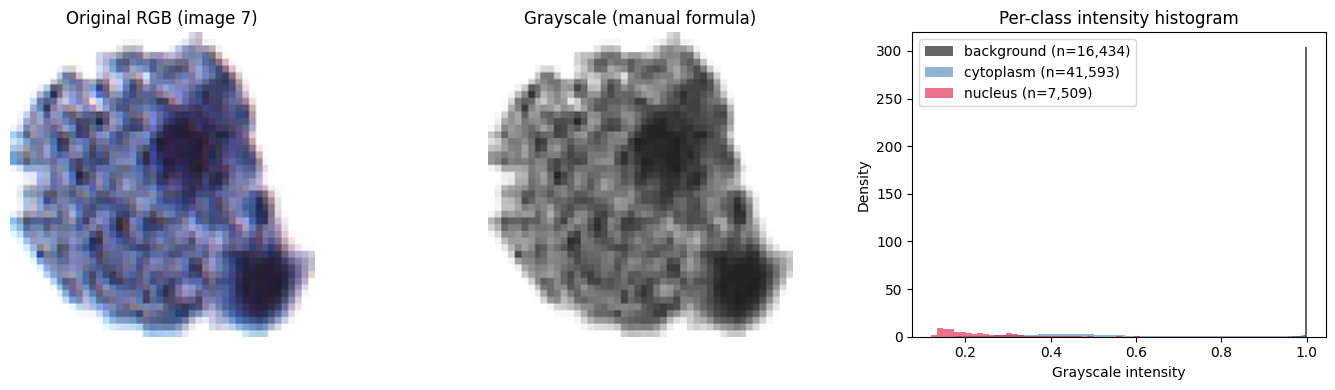

Per-class grayscale statistics for image 7:
    background: mean=0.999  std=0.008  min=0.808  max=1.000
     cytoplasm: mean=0.508  std=0.193  min=0.120  max=1.000
       nucleus: mean=0.239  std=0.113  min=0.120  max=0.934


In [6]:
# ── Visualise: original | grayscale | per-class histogram ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img7.transpose(1, 2, 0))
axes[0].set_title('Original RGB (image 7)')
axes[0].axis('off')

axes[1].imshow(gray7, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Grayscale (manual formula)')
axes[1].axis('off')

colors = ['black', 'steelblue', 'crimson']
for cls, (name, col) in enumerate(zip(['background', 'cytoplasm', 'nucleus'], colors)):
    vals = gray7[mask7 == cls]
    axes[2].hist(vals, bins=60, alpha=0.6, color=col, label=f'{name} (n={len(vals):,})',
                 density=True)
axes[2].set_xlabel('Grayscale intensity')
axes[2].set_ylabel('Density')
axes[2].set_title('Per-class intensity histogram')
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("Per-class grayscale statistics for image 7:")
for cls, name in label_names.items():
    vals = gray7[mask7 == cls]
    if len(vals):
        print(f"  {name:>12s}: mean={vals.mean():.3f}  std={vals.std():.3f}  "
              f"min={vals.min():.3f}  max={vals.max():.3f}")

## 4. Threshold Segmentation

The histogram above reveals three well-separated intensity bands:

| Class | Typical intensity | Rationale |
|---|---|---|
| Nucleus | ≈ 0.24 (dark purple) | Strongly absorbs the haematoxylin stain |
| Cytoplasm | ≈ 0.51 (pink) | Lightly stained by eosin |
| Background | ≈ 1.00 (white) | Unstained glass slide |

We introduce two thresholds:

- **`t_nucleus`** — the *maximum* grayscale value that a nucleus pixel can have.  
  Pixels with `gray < t_nucleus` are labelled nucleus.
- **`t_background`** — the *minimum* grayscale value that a background pixel can have.  
  Pixels with `gray ≥ t_background` are labelled background.
- Everything in between is labelled cytoplasm.

**Try changing the threshold values** in the cell below and re-running to see how the
segmentation and Dice scores change.

In [7]:
# ── Threshold parameters (adjust and re-run!) ─────────────────────────────────
t_nucleus    = 0.45   # pixels darker than this  →  nucleus
t_background = 0.85   # pixels brighter than this →  background
                      # everything in between     →  cytoplasm

# ── Build predicted mask ──────────────────────────────────────────────────────
pred7 = np.zeros_like(gray7, dtype=np.int64)   # default: background (0)
pred7[gray7 <  t_nucleus]                           = 2   # nucleus
pred7[(gray7 >= t_nucleus) & (gray7 < t_background)] = 1   # cytoplasm
# (pixels >= t_background stay 0 = background)

print("Predicted class counts:")
for cls, name in label_names.items():
    print(f"  {name:>12s}: {(pred7 == cls).sum():>7,}  "
          f"(ground truth: {(mask7 == cls).sum():>7,})")

Predicted class counts:
    background:  20,033  (ground truth:  16,434)
     cytoplasm:  19,582  (ground truth:  41,593)
       nucleus:  25,921  (ground truth:   7,509)


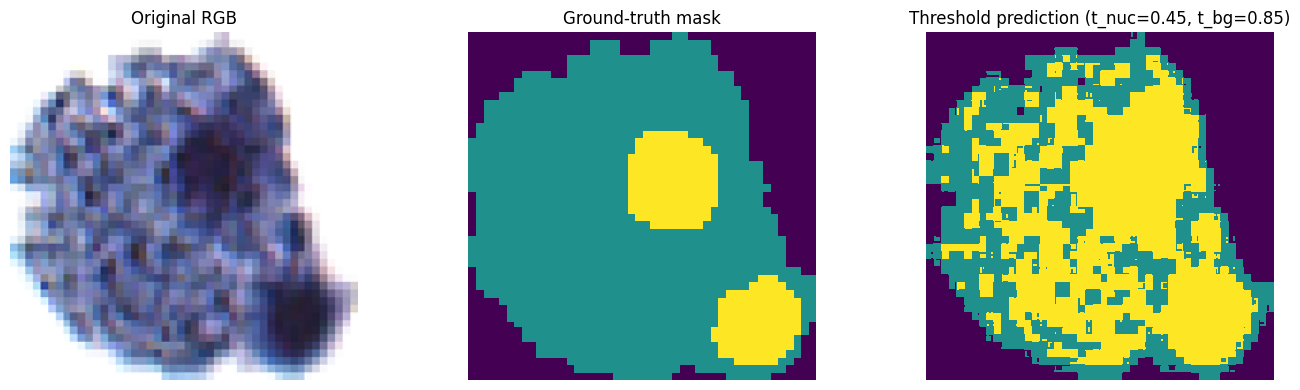

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img7.transpose(1, 2, 0))
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(mask7, cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
axes[1].set_title('Ground-truth mask')
axes[1].axis('off')

axes[2].imshow(pred7, cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
axes[2].set_title(f'Threshold prediction (t_nuc={t_nucleus}, t_bg={t_background})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 5. The Dice Score

Looking at the images gives us a qualitative sense of quality, but we need a **number**.
The most widely-used metric for segmentation tasks is the **Dice score** (also called the
F1 score or Sørensen–Dice coefficient):

$$\text{Dice}(A, B) = \frac{2\,|A \cap B|}{|A| + |B|}$$

where $A$ is the set of pixels predicted to belong to a class and $B$ is the ground-truth
set for that class.  A Dice score of **1.0** means perfect overlap; **0.0** means no overlap
at all.

We compute the Dice score separately for the **nucleus** class and the **cytoplasm** class.
Background is usually excluded from medical segmentation metrics because it dominates the
pixel count and makes scores artificially high.

In [9]:
# ── Dice score function ───────────────────────────────────────────────────────
def dice_score(pred, target, cls):
    """Binary Dice score for a single class label."""
    pred_mask   = (pred   == cls)
    target_mask = (target == cls)
    intersection = (pred_mask & target_mask).sum()
    denominator  = pred_mask.sum() + target_mask.sum()
    if denominator == 0:
        return 1.0   # both empty → perfect match by convention
    return 2 * intersection / denominator


# ── Evaluate on image 7 ───────────────────────────────────────────────────────
dice_cyto = dice_score(pred7, mask7, cls=1)
dice_nuc  = dice_score(pred7, mask7, cls=2)

print(f"Dice — cytoplasm : {dice_cyto:.4f}")
print(f"Dice — nucleus   : {dice_nuc:.4f}")
print(f"Mean Dice (cyto + nuc): {(dice_cyto + dice_nuc) / 2:.4f}")

Dice — cytoplasm : 0.6285
Dice — nucleus   : 0.4278
Mean Dice (cyto + nuc): 0.5281


Dataset-wide Dice scores  (thresholds: t_nuc=0.45, t_bg=0.85)
  Cytoplasm : 0.7144  ±  0.1396
  Nucleus   : 0.7037  ±  0.2246
  Mean      : 0.7091


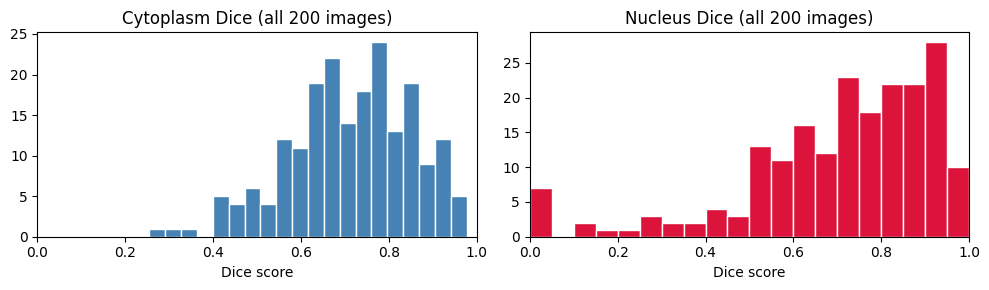

In [10]:
# ── Apply to the full dataset and report mean Dice ────────────────────────────
cyto_scores, nuc_scores = [], []

for i in range(len(X)):
    R_i, G_i, B_i = X[i, 0], X[i, 1], X[i, 2]
    gray_i = 0.299 * R_i + 0.587 * G_i + 0.114 * B_i

    pred_i = np.zeros_like(gray_i, dtype=np.int64)
    pred_i[gray_i < t_nucleus]                              = 2
    pred_i[(gray_i >= t_nucleus) & (gray_i < t_background)] = 1

    cyto_scores.append(dice_score(pred_i, y[i], cls=1))
    nuc_scores.append(dice_score(pred_i,  y[i], cls=2))

print(f"Dataset-wide Dice scores  (thresholds: t_nuc={t_nucleus}, t_bg={t_background})")
print(f"  Cytoplasm : {np.mean(cyto_scores):.4f}  ±  {np.std(cyto_scores):.4f}")
print(f"  Nucleus   : {np.mean(nuc_scores):.4f}  ±  {np.std(nuc_scores):.4f}")
print(f"  Mean      : {(np.mean(cyto_scores) + np.mean(nuc_scores)) / 2:.4f}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(cyto_scores, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Cytoplasm Dice (all 200 images)')
axes[0].set_xlabel('Dice score')
axes[1].hist(nuc_scores,  bins=20, color='crimson',   edgecolor='white')
axes[1].set_title('Nucleus Dice (all 200 images)')
axes[1].set_xlabel('Dice score')
for ax in axes:
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## Wrap-up

We have built the simplest possible segmenter — a two-threshold rule on the grayscale
intensity — and evaluated it with the Dice score across the full dataset.

**Key takeaways:**
- The three classes (background, cytoplasm, nucleus) occupy very different intensity bands,
  which is why thresholding works at all.
- Threshold selection is fragile: a value that works well for one image may fail on another
  due to staining variation and illumination differences.
- Deep learning will learn these decision boundaries **automatically** from the data,
  and generalise far better to new images.

---

## Group Exercise — Measuring the N/C Ratio

The whole point of this project is to predict the **nucleus-to-cytoplasm (N/C) ratio**,
defined as:

$$\text{N/C ratio} = \frac{\text{number of nucleus pixels}}{\text{number of cytoplasm pixels}}$$

A high N/C ratio is a hallmark of malignant cells in cytopathology.

Your group of three will divide the work below, then share results and discuss.

---

### Person A — Write the `nc_ratio` function

Fill in the function below. It receives a mask (a 2D array of labels `0`, `1`, `2`) and
returns the N/C ratio as a float.

```python
def nc_ratio(mask):
    nucleus_pixels    = (mask == 2).sum()
    cytoplasm_pixels  = (mask == 1).sum()
    # What should we return if there is no cytoplasm?
    if cytoplasm_pixels == 0:
        return float('nan')
    return nucleus_pixels / cytoplasm_pixels
```

Once written, test it on the ground-truth mask for image 7:
```python
print(nc_ratio(y[7]))
```

---

### Person B — Ground-truth N/C ratios

Using Person A's function, compute the ground-truth N/C ratio for images `10, 20, 30, 40, 50`
and store the results in a list called `gt_ratios`.

```python
images_to_check = [10, 20, 30, 40, 50]
gt_ratios = [nc_ratio(y[i]) for i in images_to_check]

for idx, ratio in zip(images_to_check, gt_ratios):
    print(f"Image {idx:3d} — ground-truth N/C ratio: {ratio:.3f}")
```

---

### Person C — Predicted N/C ratios

Using the same threshold segmenter from Section 4, generate predicted masks for the same
five images and compute their N/C ratios. Store them in `pred_ratios`.

```python
pred_ratios = []
for i in images_to_check:
    R, G, B  = X[i, 0], X[i, 1], X[i, 2]
    gray     = 0.299 * R + 0.587 * G + 0.114 * B
    pred     = np.zeros_like(gray, dtype=np.int64)
    pred[gray < t_nucleus]                               = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1
    pred_ratios.append(nc_ratio(pred))

for idx, ratio in zip(images_to_check, pred_ratios):
    print(f"Image {idx:3d} — predicted  N/C ratio: {ratio:.3f}")
```

---

### All together — Compare and discuss

Once all three parts are done, run the cell below to compare ground-truth vs predicted N/C
ratios side by side.

```python
print(f"{'Image':>6}  {'Ground truth':>14}  {'Predicted':>10}  {'Error':>8}")
for idx, gt, pr in zip(images_to_check, gt_ratios, pred_ratios):
    err = abs(gt - pr)
    print(f"{idx:6d}  {gt:14.3f}  {pr:10.3f}  {err:8.3f}")
```

**Discussion questions for your group:**
1. For which image is the predicted N/C ratio closest to the ground truth? Visualise that image — why does thresholding work well there?
2. For which image is the error largest? Look at its histogram. What is different about it?
3. If a pathologist needs the N/C ratio to be accurate to within ±0.05, does thresholding meet that bar? What would it take to do better?

---

## Addendum — N/C Ratio: Predicted vs True (full dataset)

The scatter plot below applies the same two-threshold segmenter to all 200 images
and compares each predicted N/C ratio to the ground-truth value.
Points on the dashed line are perfect predictions; scatter above or below indicates
systematic over- or under-estimation.

The quality metric is **R² vs y = x**: the coefficient of determination measured
against the *identity* line, not a fitted regression:

$$R^2 = 1 - \frac{\sum_i(\hat{y}_i - y_i)^2}{\sum_i(y_i - \bar{y})^2}$$

R² = 1 means every prediction lies exactly on y = x; it falls whenever predictions
deviate from perfect agreement, whether by bias, scale, or scatter.
Unlike Pearson r, it will improve as our segmenters improve.

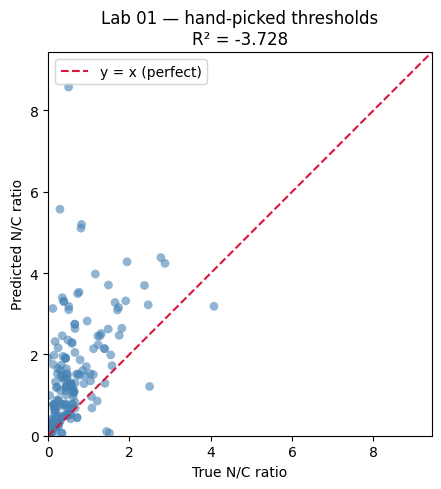

In [11]:
# ── N/C ratio for every image (full dataset, same thresholds as above) ────────────
def nc_ratio(mask):
    """N/C ratio: nucleus pixels / cytoplasm pixels.  NaN if cytoplasm absent."""
    nuc = (mask == 2).sum()
    cyt = (mask == 1).sum()
    return nuc / cyt if cyt > 0 else np.nan

nc_true = np.zeros(N)
nc_pred = np.zeros(N)

for i in range(N):
    R_i, G_i, B_i = X[i, 0], X[i, 1], X[i, 2]
    gray_i = 0.299 * R_i + 0.587 * G_i + 0.114 * B_i

    pred_i = np.zeros_like(gray_i, dtype=np.int64)
    pred_i[gray_i < t_nucleus]                               = 2
    pred_i[(gray_i >= t_nucleus) & (gray_i < t_background)]  = 1

    nc_true[i] = nc_ratio(y[i])
    nc_pred[i] = nc_ratio(pred_i)

valid = np.isfinite(nc_true) & np.isfinite(nc_pred)
x, yp = nc_true[valid], nc_pred[valid]

# R² vs y = x: residuals from the identity line, not a fitted regression line
ss_res = np.sum((yp - x) ** 2)
ss_tot = np.sum((x - x.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, yp, alpha=0.6, color='steelblue', edgecolors='none', s=40)

lim = max(x.max(), yp.max()) * 1.1
ax.plot([0, lim], [0, lim], color='crimson', linestyle='--',
        linewidth=1.5, label='y = x (perfect)')

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.set_xlabel('True N/C ratio')
ax.set_ylabel('Predicted N/C ratio')
ax.set_title(f'Lab 01 — hand-picked thresholds\nR² = {r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()